# BurstGPT Week-1 Data Quality Audit

## tl;dr

三个 `without_fails` 文件的真实字段已逐一抽样。1/2号不含 Session 或耗时；3号虽有 Session，但它对全部 API 记录结构性缺失。全量清洗未发现坏时间、非数值/负 Token 或关键字段缺失，删除全部来自公开字段完全相同的记录。1/2号分别保留 1,363,384 和 3,695,526 行；`complete_1` 的零响应失败率为 1.7796%。

## Context & Methods

粒度为一次 LLM 请求。主实验使用 without-fails 1/2号，3号只作跨时期稳健性测试，complete_1只作失败审计。清洗与审计由 `src/01_clean.py` 以20万行分块执行。

### Key Assumptions

- `Timestamp` 是相对秒数；转换后的1970日期只是合成UTC轴，不是采集日期。
- 失败条件是 `Response tokens == 0`，依据 BurstGPT 论文第1节（PDF第2页）。
- 公开字段完全相同的行按验收规则去重；因无请求ID，仍需把潜在低估并发负载列为局限。

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'Dataset').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATASET_DIR = PROJECT_ROOT / 'Dataset'
WITHOUT_FAILS = sorted(DATASET_DIR.glob('level_5_*without_fails_*.csv'))
assert len(WITHOUT_FAILS) == 3, WITHOUT_FAILS
WITHOUT_FAILS

[WindowsPath('F:/A - 科研项目/Project/LLM服务的Token负载预测与突发流量识别——基于BurstGPT真实轨迹的XGBoost与LSTM比较/Dataset/level_5_BurstGPT_v2.0_without_fails_1_Undisclosed_GitHub.csv'),
 WindowsPath('F:/A - 科研项目/Project/LLM服务的Token负载预测与突发流量识别——基于BurstGPT真实轨迹的XGBoost与LSTM比较/Dataset/level_5_BurstGPT_v2.0_without_fails_2_Undisclosed_GitHub.csv'),
 WindowsPath('F:/A - 科研项目/Project/LLM服务的Token负载预测与突发流量识别——基于BurstGPT真实轨迹的XGBoost与LSTM比较/Dataset/level_5_BurstGPT_v2.0_without_fails_3_Undisclosed_GitHub.csv')]

## Data

### 1. Inspect exact source columns, inferred dtypes, and five rows

In [2]:
samples = {}
for path in WITHOUT_FAILS:
    df = pd.read_csv(path, nrows=5)
    samples[path.name] = df
    print(f'\n=== {path.name} ===')
    display(df.columns.tolist())
    display(df.dtypes)
    display(df.head().T)


=== level_5_BurstGPT_v2.0_without_fails_1_Undisclosed_GitHub.csv ===


['Timestamp',
 'Model',
 'Request tokens',
 'Response tokens',
 'Total tokens',
 'Log Type']

Timestamp          int64
Model                str
Request tokens     int64
Response tokens    int64
Total tokens       int64
Log Type             str
dtype: object

,0,1,2,3,4
Timestamp,5,45,118,185,214
Model,ChatGPT,ChatGPT,GPT-4,ChatGPT,ChatGPT
Request tokens,472,1087,417,1360,185
Response tokens,18,230,276,647,215
Total tokens,490,1317,693,2007,400
Log Type,Conversation log,Conversation log,Conversation log,Conversation log,Conversation log



=== level_5_BurstGPT_v2.0_without_fails_2_Undisclosed_GitHub.csv ===


...

,0,1,2,3,4
Timestamp,5270414.0,5270433.0,5270463.0,5270473.0,5270551.0
Model,ChatGPT,ChatGPT,GPT-4,ChatGPT,GPT-4
Request tokens,708,1533,2419,772,309
Response tokens,34,403,484,26,178
Total tokens,742,1936,2903,798,487
Log Type,Conversation log,Conversation log,Conversation log,Conversation log,Conversation log



=== level_5_BurstGPT_v2.0_without_fails_3_Undisclosed_GitHub.csv ===


['Timestamp',
 'Session ID',
 'Elapsed time',
 'Model',
 'Request tokens',
 'Response tokens',
 'Total tokens',
 'Log Type']

Timestamp          float64
Session ID             str
Elapsed time         int64
Model                  str
Request tokens       int64
Response tokens      int64
Total tokens         int64
Log Type               str
dtype: object

,0,1,2,3,4
Timestamp,19440110.0,19440161.0,19440192.0,19440254.0,19440301.0
Session ID,1722ac82-0a46-4bf0-aa08-89794e7a2b3f,d5983bf9-4b48-497b-892b-a58995247443,a5c69b35-4fbc-45e9-955e-18715e376d74,8b74c7d8-1643-4bba-8c69-91cb4548c506,1722ac82-0a46-4bf0-aa08-89794e7a2b3f
Elapsed time,43,2,8,3,26
Model,GPT-4,ChatGPT,GPT-4,ChatGPT,GPT-4
Request tokens,906,36,1779,935,1631
Response tokens,446,29,123,178,282
Total tokens,1352,65,1902,1113,1913
Log Type,Conversation log,Conversation log,Conversation log,Conversation log,Conversation log


## Results

### 2. Review file-level quality and sequential deletions

In [3]:
quality_path = PROJECT_ROOT / 'outputs' / 'tables' / 'table_00_data_quality.csv'
quality = pd.read_csv(quality_path)
summary_columns = [
    'file_id', 'role', 'raw_rows', 'clean_rows', 'deletion_ratio',
    'raw_duplicate_rows', 'zero_output_token_ratio',
    'timestamp_min_relative_seconds', 'timestamp_max_relative_seconds',
    'max_inter_request_gap_seconds_in_file_order',
    'gaps_over_one_hour_in_file_order',
]
display(quality[[c for c in summary_columns if c in quality.columns]])
missing_columns = ['file_id'] + [c for c in quality.columns if c.startswith('missing_rate__')]
display(quality[missing_columns])

,file_id,role,raw_rows,clean_rows,deletion_ratio,raw_duplicate_rows,zero_output_token_ratio,timestamp_min_relative_seconds,timestamp_max_relative_seconds,max_inter_request_gap_seconds_in_file_order,gaps_over_one_hour_in_file_order
0,without_fails_1,main_experiment,1404294,1363384.0,0.029132,40910.0,0.000000,5.0,5269973.0,15240.0,49.0
1,without_fails_2,main_experiment,3784213,3695526.0,0.023436,88687.0,0.000000,5270414.0,10454395.0,37133.0,60.0
2,without_fails_3,robustness_only,4956058,4805535.0,0.030372,150523.0,0.000000,19440110.0,28943983.0,18872.0,57.0
3,complete_1,failure_audit_only,1429737,NaN,NaN,NaN,0.017796,NaN,NaN,NaN,NaN


,file_id,missing_rate__log_type,missing_rate__model,missing_rate__request_tokens,missing_rate__response_tokens,missing_rate__timestamp,missing_rate__total_tokens,missing_rate__elapsed_time,missing_rate__session_id
0,without_fails_1,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,without_fails_2,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,without_fails_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.953237
3,complete_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
deletions = pd.read_csv(PROJECT_ROOT / 'outputs' / 'tables' / 'table_00_cleaning_steps.csv')
display(deletions)
assert (deletions['raw_rows'] - deletions['clean_rows'] == deletions.filter(like='deleted_').sum(axis=1)).all()

,file_id,raw_rows,deleted_unparseable_timestamp,deleted_non_numeric_tokens,deleted_negative_tokens,deleted_critical_missing,deleted_duplicates,clean_rows
0,without_fails_1,1404294,0.0,0.0,0.0,0.0,40910.0,1363384.0
1,without_fails_2,3784213,0.0,0.0,0.0,0.0,88687.0,3695526.0
2,without_fails_3,4956058,0.0,0.0,0.0,0.0,150523.0,4805535.0


### 3. Reconcile the Parquet outputs and two-day smoke test

In [5]:
parquet_checks = []
for batch in ('1', '2'):
    frame = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / f'requests_{batch}.parquet')
    row = quality.loc[quality['file_id'].eq(f'without_fails_{batch}')].iloc[0]
    assert len(frame) == int(row['clean_rows'])
    assert frame['timestamp'].notna().all()
    assert (frame[['request_tokens', 'response_tokens', 'total_tokens']] >= 0).all().all()
    assert (frame['request_tokens'] + frame['response_tokens'] == frame['total_tokens']).all()
    assert not frame.duplicated(subset=[c for c in frame.columns if c != 'source_batch']).any()
    parquet_checks.append({'batch': batch, 'rows': len(frame), 'total_tokens': int(frame['total_tokens'].sum())})
display(pd.DataFrame(parquet_checks))

,batch,rows,total_tokens
0,1,1363384,1039937954
1,2,3695526,1106930193


In [6]:
smoke = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'smoke_2days_5min.csv')
assert len(smoke) == 576
assert int(smoke['request_count'].sum()) == 6107
assert (smoke['request_tokens_sum'] + smoke['response_tokens_sum'] == smoke['total_tokens']).all()
assert int(smoke['total_tokens'].sum()) == 5_694_880
display(smoke.head())
display(smoke[['request_count', 'request_tokens_sum', 'response_tokens_sum', 'total_tokens']].sum().to_frame('two_day_total'))

,bin_start_relative_seconds,bin_start_synthetic_utc,request_count,request_tokens_sum,response_tokens_sum,total_tokens
0,0,1970-01-01 00:00:00+00:00,8,4198,3838,8036
1,300,1970-01-01 00:05:00+00:00,3,2166,1146,3312
2,600,1970-01-01 00:10:00+00:00,5,3065,1152,4217
3,900,1970-01-01 00:15:00+00:00,5,2957,1557,4514
4,1200,1970-01-01 00:20:00+00:00,2,618,939,1557


,two_day_total
request_count,6107
request_tokens_sum,4097782
response_tokens_sum,1597098
total_tokens,5694880


### 4. Inspect diagnostic distributions

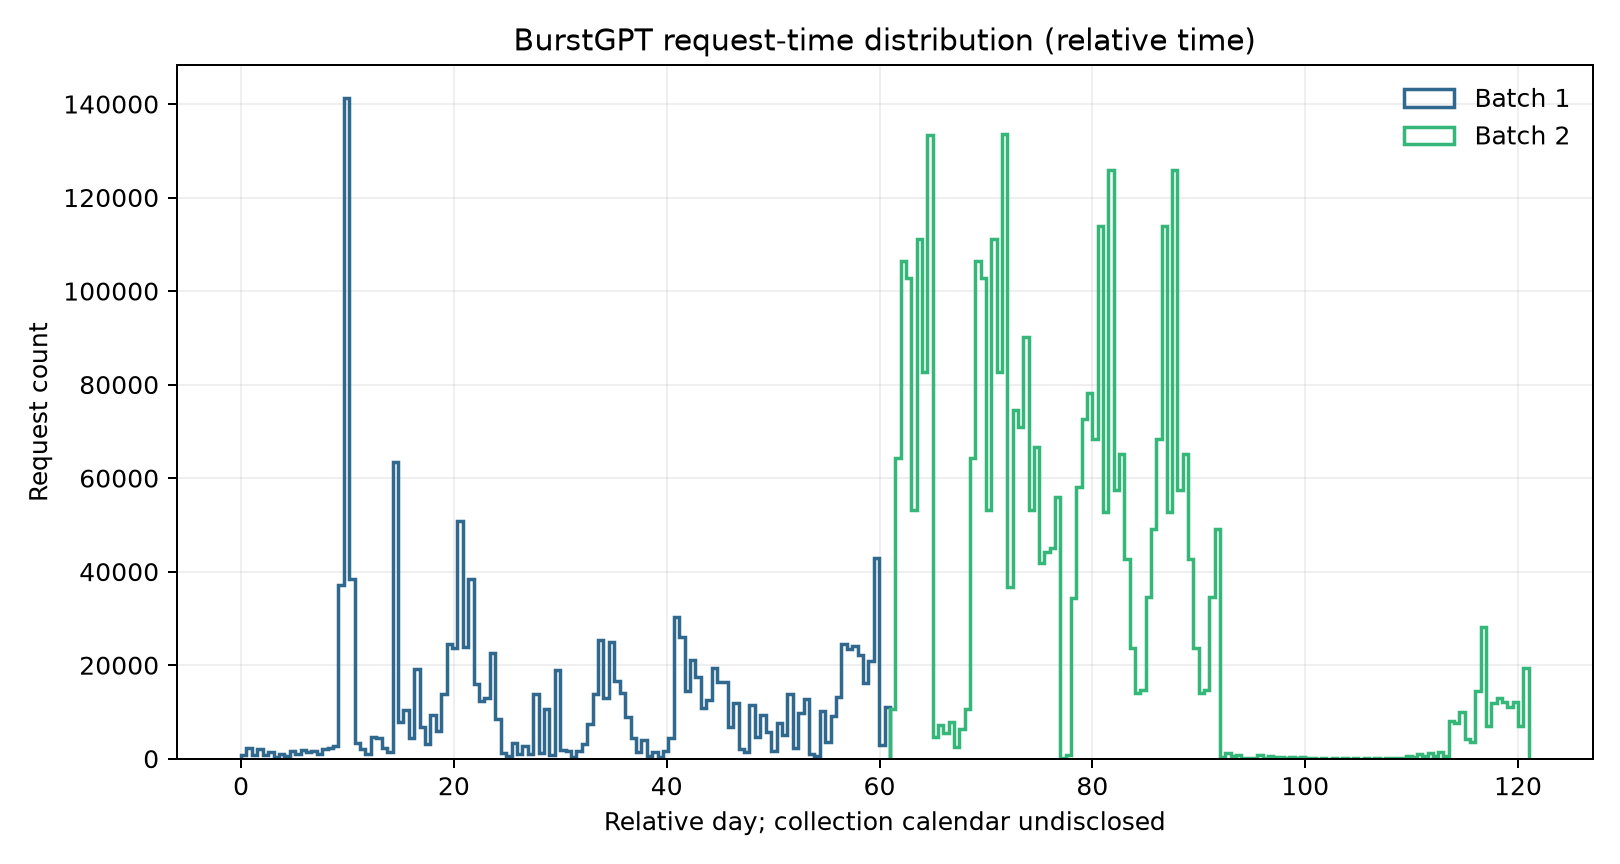

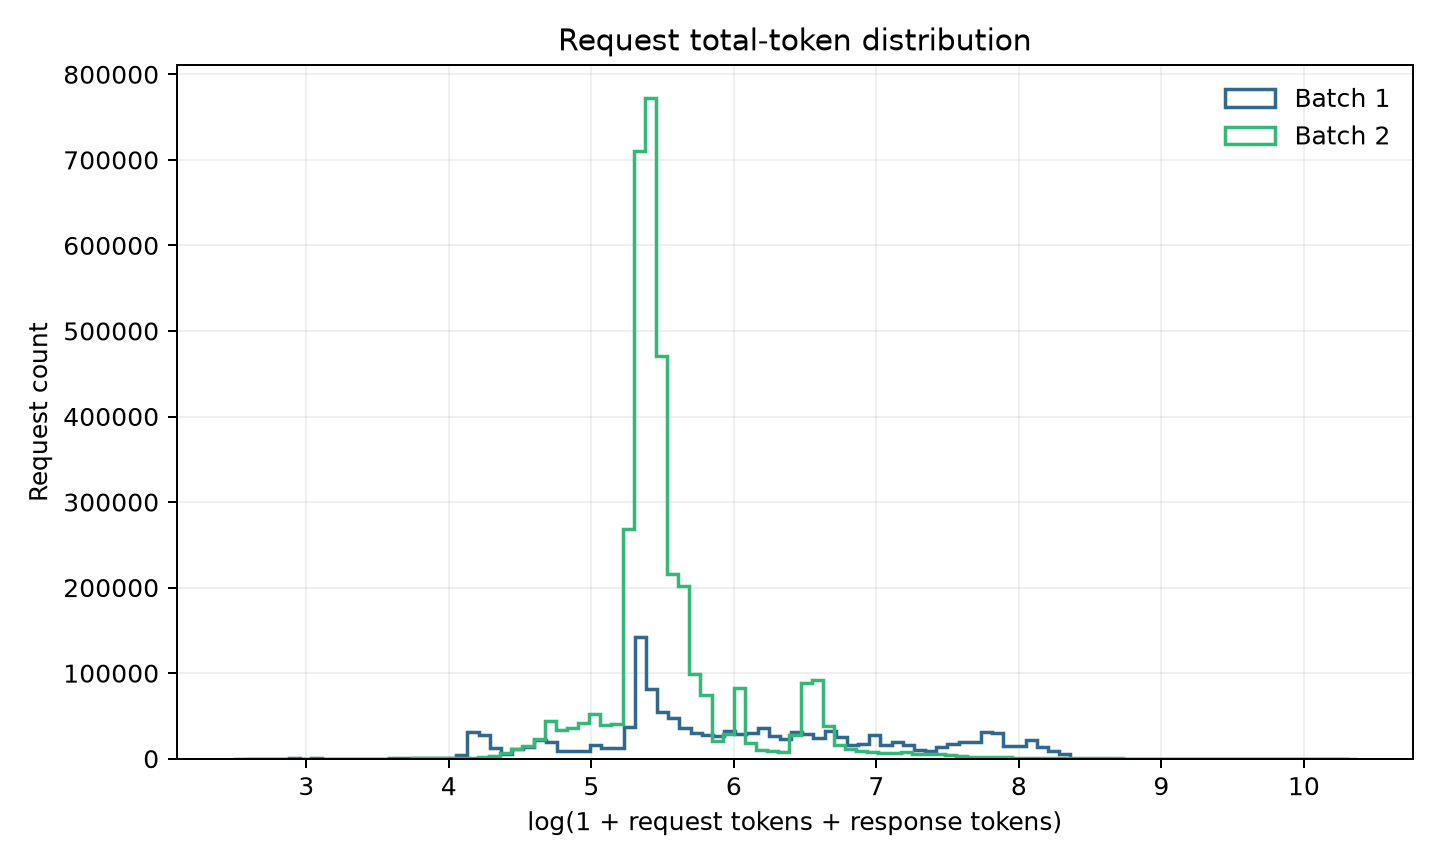

In [7]:
display(Image(filename=str(PROJECT_ROOT / 'outputs' / 'figures' / 'fig_00_request_time_histogram.png')))
display(Image(filename=str(PROJECT_ROOT / 'outputs' / 'figures' / 'fig_00_total_tokens_log_histogram.png')))

## Takeaways

1. 1/2号字段一致且时间边界只差441秒，可保留批次标记后作为主序列；3号与2号相隔约104天，只作跨时期测试。
2. 去重是唯一发生删除的规则，但没有请求ID，故该处理可能误删同秒并发的同属性请求；后续应报告敏感性分析。
3. 三个批次均有多处超过1小时的无请求空窗，最长约4.23、10.31、5.24小时；无法仅凭轨迹区分真实零需求和采集断层。
4. Session、耗时、真实星期/周末不进入主模型；模型与日志类型只能作为历史窗口特征。